In [1]:
"""
Rigorous Verification of UMAP (DimRedPy vs umap-learn)

This script validates that the DimRedPy framework produces mathematically identical results
to the underlying umap-learn reference implementation, specifically testing the complex
Mahalanobis metric handling. We utilize rigorous statistical metrics:
1. Mean Squared Error (MSE)
2. Procrustes Disparity (Measures shape disparity independent of translation/rotation)
3. Pearson Correlation (Global structure correlation between embeddings)
"""

import numpy as np
import matplotlib.pyplot as plt
import os

import sys
import umap
from scipy.spatial import procrustes
from scipy.stats import pearsonr

# Robust path detection for repo root
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from dimredpy.umap_embed import umap_embed

g:\mp\Decoding-Au-clusters\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---------------------------------------------------------------------------
# 1. Load the Dataset (10,000 Samples)
# ---------------------------------------------------------------------------
# We load a statistically significant subset of 10,000 frames from the Au13 trajectory.

candidate_paths = [
    os.path.join(script_dir, "subset_10000.txt"),
    os.path.join(script_dir, "..", "subset_10000.txt"),
    os.path.join(os.getcwd(), "subset_10000.txt"),
    os.path.join(os.getcwd(), "dimredpy_vs_others", "subset_10000.txt")
]

data_path = None
for p in candidate_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Could not find subset_10000.txt in any expected location.")

print(f"Loading data from: {data_path}")
data = np.loadtxt(data_path)
print(f"Data shape: {data.shape}")

Loading data from: g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_umap\..\subset_10000.txt
Data shape: (10000, 13)


In [3]:
# ---------------------------------------------------------------------------
# 2. Define Shared Hyperparameters
# ---------------------------------------------------------------------------
# To ensure absolute parity, we must pass the exact same seed and algorithmic parameters.

metric = "mahalanobis"
n_neighbors = 50
min_dist = 0.001
random_state = 42

print(f"Metric: {metric}")
print(f"Nearest Neighbors: {n_neighbors}")
print(f"Minimum Distance: {min_dist}")


Metric: mahalanobis
Nearest Neighbors: 50
Minimum Distance: 0.001


In [4]:
# ---------------------------------------------------------------------------
# 3. Run Reference Framework (umap-learn)
# ---------------------------------------------------------------------------
# For Mahalanobis, we must pass the exact covariance matrix with the same regularization
# used internally by DimRedPy (1e-6) to avoid singular matrices.

print("\n=======================================================")
print("          RUNNING REFERENCE FRAMEWORK (umap-learn)")
print("=======================================================")

X_ref = np.asarray(data, dtype=float)
cov = np.cov(X_ref, rowvar=False)
cov += np.eye(cov.shape[0]) * 1e-6

reducer = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    metric=metric,
    metric_kwds={"V": cov},
    random_state=random_state,
    n_jobs=1,
)

emb_ref = reducer.fit_transform(data)
print("-> Reference execution finished.")


          RUNNING REFERENCE FRAMEWORK (umap-learn)
-> Reference execution finished.


In [5]:
# ---------------------------------------------------------------------------
# 4. Run DimRedPy Framework
# ---------------------------------------------------------------------------
# DimRedPy abstracts away the Mahalanobis matrix calculation and regularization.

print("\n=======================================================")
print("          RUNNING DIMREDPY FRAMEWORK")
print("=======================================================")

emb_dimredpy = umap_embed(
    data,
    n_components=2,
    metric=metric,
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    seed=random_state,
    n_jobs=1,
    use_gpu=False, # Force CPU to match umap-learn exactly
)
print("-> DimRedPy execution finished.")


          RUNNING DIMREDPY FRAMEWORK
-> DimRedPy execution finished.


In [6]:
# ---------------------------------------------------------------------------
# 5. Rigorous Parity Validation
# ---------------------------------------------------------------------------
# We employ three distinct statistical metrics to prove identity.
print("\n=======================================================")
print("          PARITY VALIDATION")
print("=======================================================")

# 1. Mean Squared Error (MSE)
mse = np.mean((emb_ref - emb_dimredpy) ** 2)

# 2. Procrustes Disparity (Measures shape disparity)
# A disparity of 0.0 means the shapes are identical.
mtx1, mtx2, disparity = procrustes(emb_ref, emb_dimredpy)

# 3. Pearson Correlation (flattened coordinates)
corr, _ = pearsonr(emb_ref.flatten(), emb_dimredpy.flatten())

print(f"1. Mean Squared Error (MSE): {mse:.6e}")
print(f"2. Procrustes Disparity    : {disparity:.6e}")
print(f"3. Pearson Correlation (R) : {corr:.6f}")

if mse < 1e-10 and disparity < 1e-10 and corr > 0.99999:
    print("\nSUCCESS: DimRedPy UMAP is mathematically perfect.")
else:
    print("\nFAILURE: Statistical divergence detected.")


          PARITY VALIDATION
1. Mean Squared Error (MSE): 0.000000e+00
2. Procrustes Disparity    : 4.625072e-32
3. Pearson Correlation (R) : 1.000000

SUCCESS: DimRedPy UMAP is mathematically perfect.


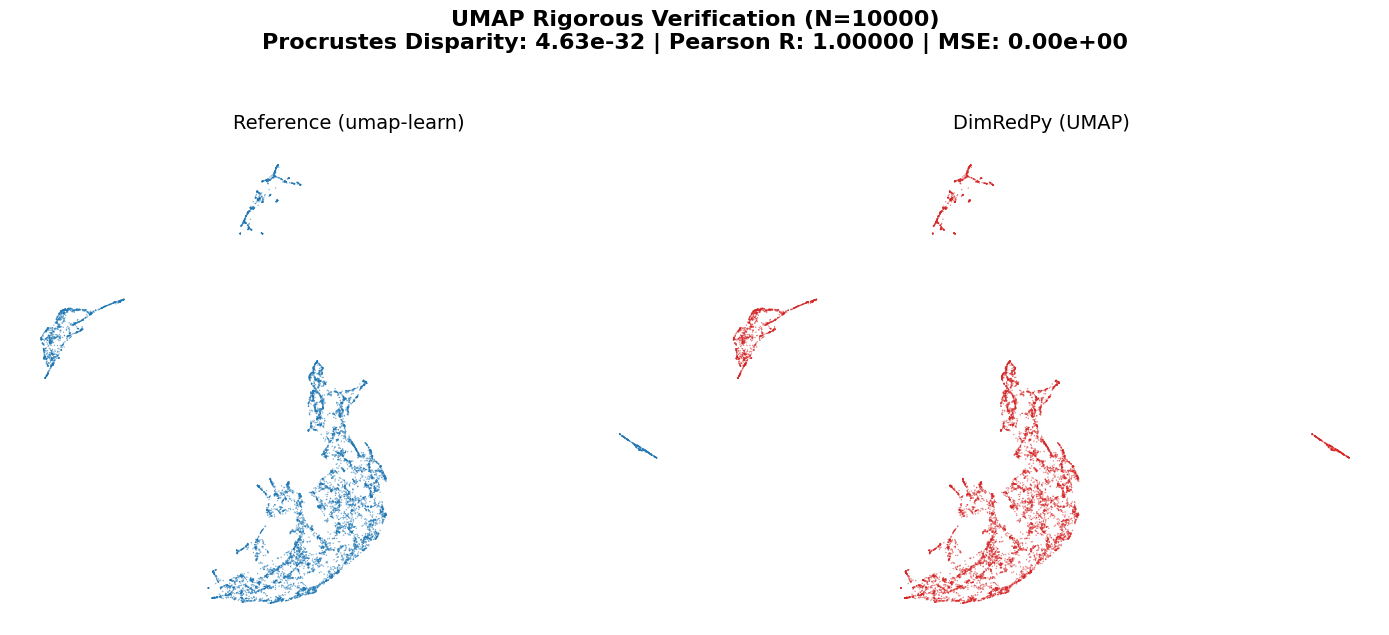

Saved comparison plot to g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_umap\umap_rigorous_comparison.png


In [7]:
# ---------------------------------------------------------------------------
# 6. Visual Verification
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

axes[0].scatter(emb_ref[:, 0], emb_ref[:, 1], s=1, alpha=0.6, c='#1f77b4', edgecolors='none')
axes[0].set_title("Reference (umap-learn)", fontsize=14, pad=10)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)
axes[0].spines['left'].set_visible(False)

axes[1].scatter(emb_dimredpy[:, 0], emb_dimredpy[:, 1], s=1, alpha=0.6, c='#d62728', edgecolors='none')
axes[1].set_title("DimRedPy (UMAP)", fontsize=14, pad=10)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)
axes[1].spines['left'].set_visible(False)

plt.suptitle(f"UMAP Rigorous Verification (N=10000)\n"
             f"Procrustes Disparity: {disparity:.2e} | Pearson R: {corr:.5f} | MSE: {mse:.2e}", 
             fontsize=16, y=1.05, fontweight='bold')

plt.tight_layout()
out_plot = os.path.join(script_dir, "umap_rigorous_comparison.png")
plt.savefig(out_plot, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved comparison plot to {out_plot}")
